In [3]:
import xarray as xr
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [4]:
ds = xr.open_dataset("/home/has/data/sources/icon/ICON312_v1.0.0.zarr")
data = ds['rain_gsp_rate'].isel(time=200)

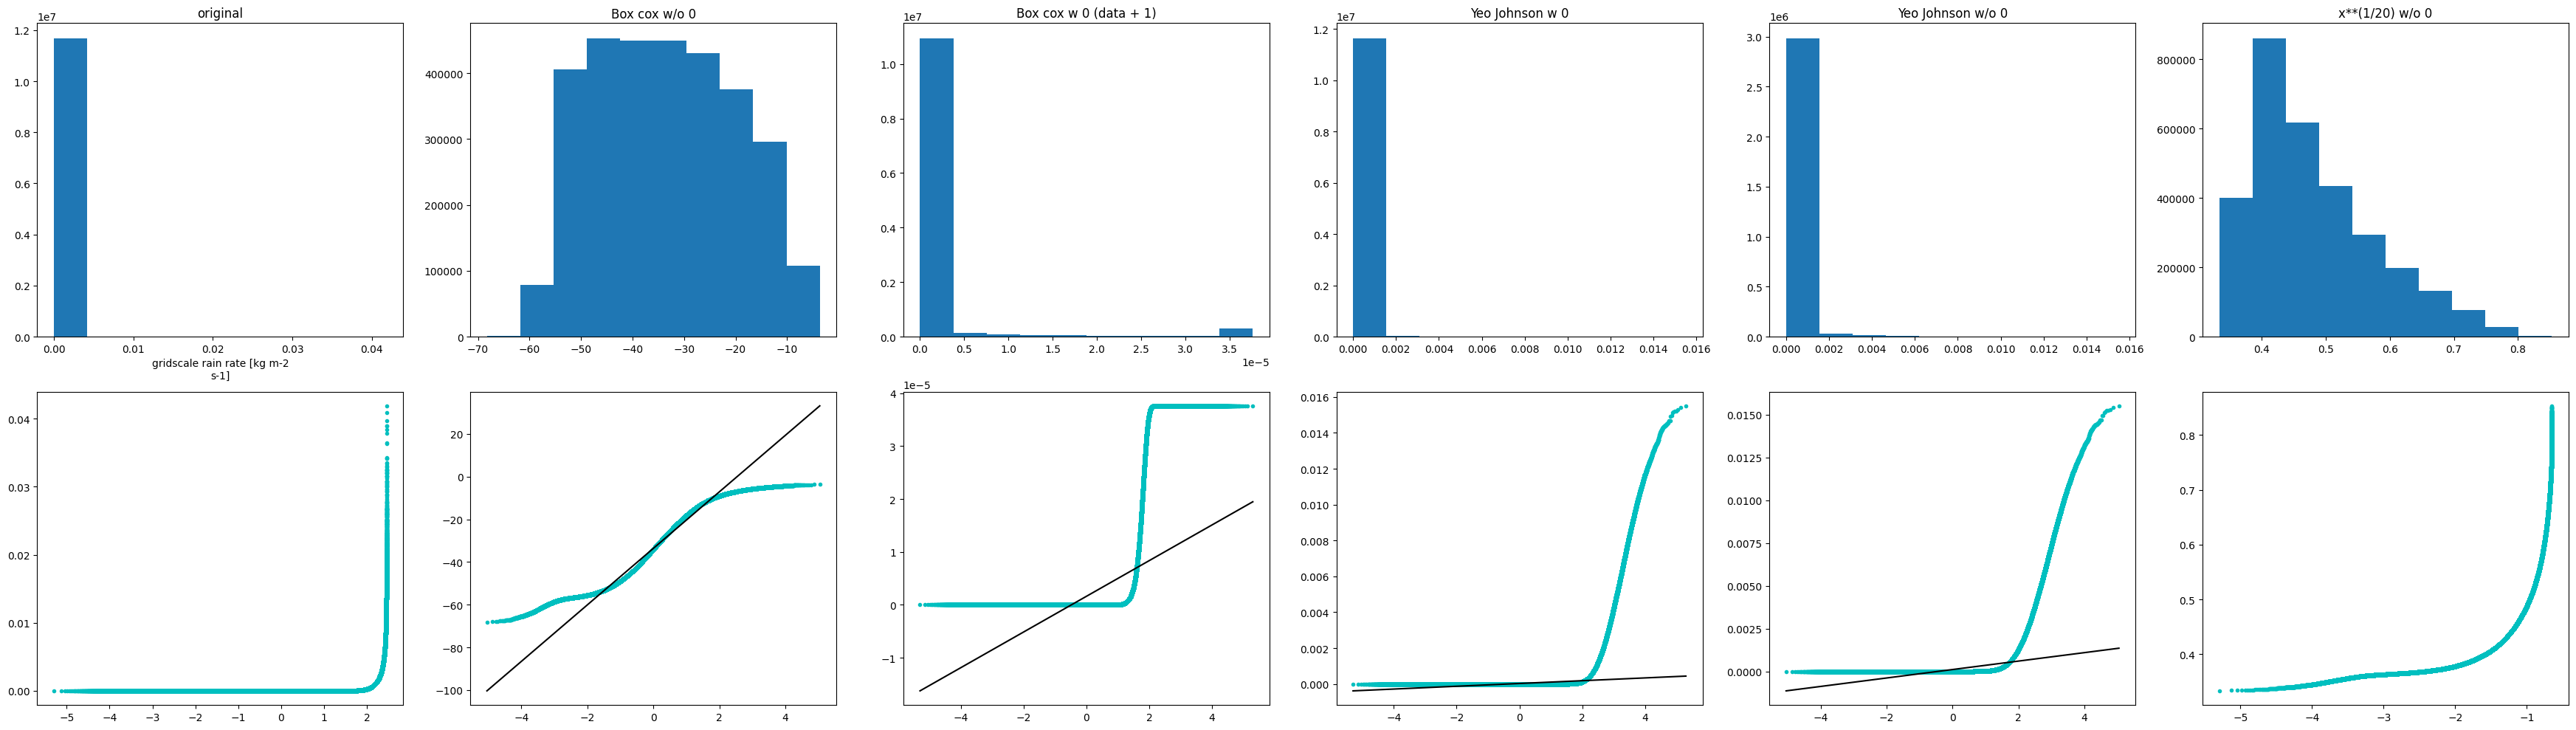

In [55]:
fig = plt.figure(figsize=(35,10))
axes = fig.subplots(2,6);
fax = axes.flatten()
#Original data
data.plot.hist(ax=fax[0]);
fax[0].set_title('original')
(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data)
fax[6].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#Boxcox
fax[1].set_title('Box cox w/o 0')
data_transformed = scipy.stats.boxcox(data.where(data>0).dropna('cell'));
fax[1].hist(data_transformed[0]);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed[0])
fax[7].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#Boxcox
fax[2].set_title('Box cox w 0 (data + 1)')
data_transformed = scipy.stats.boxcox((data+1).dropna('cell'));
fax[2].hist(data_transformed[0]);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed[0])
fax[8].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#YeoJohnson (incl. zeros)
fax[3].set_title('Yeo Johnson w 0')
data_transformed = scipy.stats.yeojohnson(data.dropna('cell'));
fax[3].hist(data_transformed[0]);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed[0])
fax[9].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#YeoJohnson (excl. zeros)
fax[4].set_title('Yeo Johnson w/o 0')
data_transformed = scipy.stats.yeojohnson(data.where(data>0).dropna('cell'));
fax[4].hist(data_transformed[0]);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed[0])
fax[10].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

#Root
fax[5].set_title('x**(1/20) w/o 0')
data_transformed = data.where(data>0)**(1/20)
fax[5].hist(data_transformed);

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed)
fax[11].plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

plt.tight_layout()


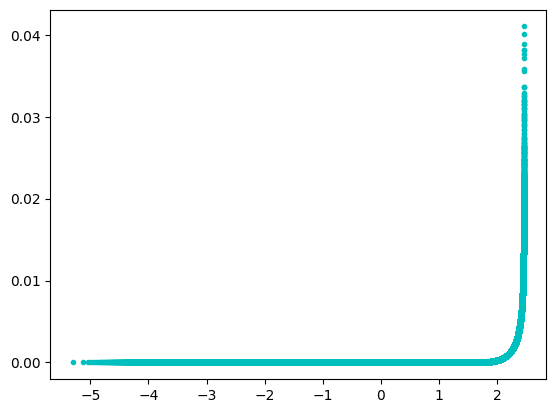

In [56]:
data_transformed = np.sign(data)*np.log(np.abs(data)+1)

(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed)
plt.plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

-68.249306


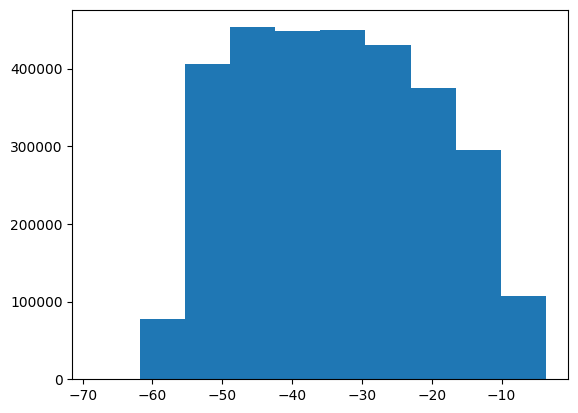

In [57]:
data_transformed = scipy.stats.boxcox(data.where(data>0).dropna('cell'));
plt.hist(data_transformed[0]);
print(np.min(data_transformed[0]))

In [58]:
data_transformed[1]

-0.08907066350763708

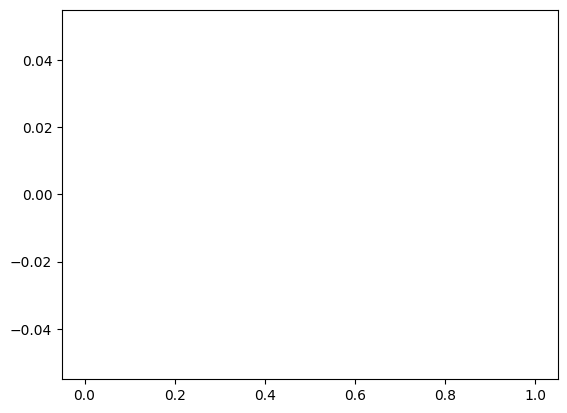

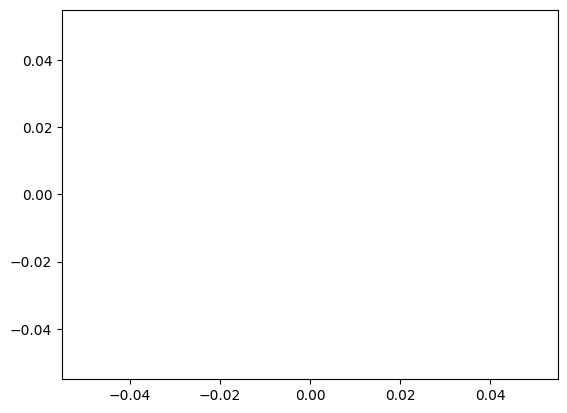

In [61]:
data_transformed = scipy.stats.boxcox(data.where(data>0.1).dropna('cell'), lmbda=-0.1)
plt.hist(data_transformed);

plt.figure()
(osm, osr), (slope, intercept, r_sq) = scipy.stats.probplot(data_transformed)
plt.plot(osm, osr, 'c.', osm, slope*osm + intercept, 'k-')

In [28]:
lmbda = -0.1
y = data_transformed
x = (lmbda*y + 1)**1/lmbda

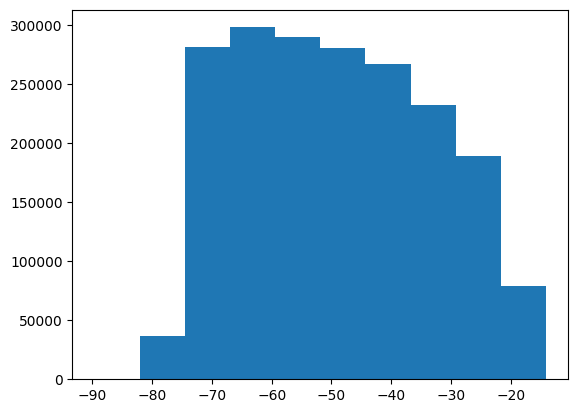

In [29]:
plt.hist(x);

(array([1.940635e+06, 9.976000e+03, 2.911000e+03, 1.122000e+03,
        4.450000e+02, 1.580000e+02, 5.600000e+01, 1.400000e+01,
        2.000000e+00, 3.000000e+00]),
 array([3.00036024e-10, 3.14166420e-03, 6.28332840e-03, 9.42499191e-03,
        1.25666559e-02, 1.57083198e-02, 1.88499838e-02, 2.19916478e-02,
        2.51333117e-02, 2.82749757e-02, 3.14166397e-02]),
 <BarContainer object of 10 artists>)

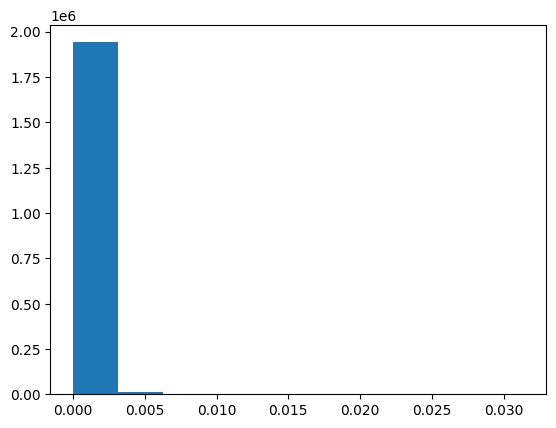

In [31]:
plt.hist(scipy.special.inv_boxcox(y, -0.1))

In [33]:
scipy.special.inv_boxcox(y, -0.1) == data.where(data>0).dropna('cell')

<xarray.DataArray 'rain_gsp_rate' (cell: 1955322)> Size: 2MB
array([False,  True, False, ..., False, False, False])
Coordinates:
  * cell     (cell) int64 16MB 81916 81917 81918 ... 11791796 11791799 11791806
    clat     (cell) float64 16MB 0.2039 0.2039 0.2039 ... 0.164 0.164 0.164
    clon     (cell) float64 16MB -0.8205 -0.8206 -0.8206 ... -1.046 -1.046
    time     datetime64[ns] 8B 2020-01-12
Attributes:
    CDI_grid_type:                unstructured
    long_name:                    gridscale rain rate
    number_of_grid_in_reference:  1
    param:                        77.1.0
    standard_name:                rain_gsp_rate
    units:                        kg m-2 s-1

In [48]:
assert np.allclose(scipy.special.inv_boxcox(y, -0.1), data.where(data>0).dropna('cell'))

In [53]:
import cartopy.crs as ccrs

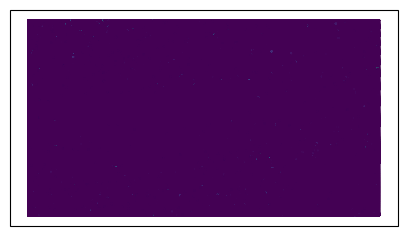

In [52]:
fig, ax = plt.subplots(
    figsize=(5, 4.8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
plt.scatter(
        data.clon,
        data.clat,
        c=data.values,
        s=0.05,
        transform=ccrs.PlateCarree(),
    )

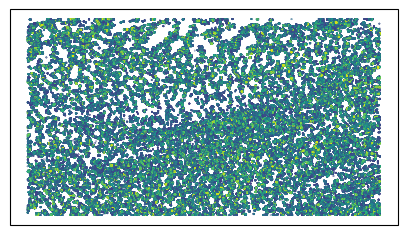

In [53]:
fig, ax = plt.subplots(
    figsize=(5, 4.8),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
plt.scatter(
        data.where(data>0).dropna('cell').clon,
        data.where(data>0).dropna('cell').clat,
        c=data_transformed,
        s=0.05,
        transform=ccrs.PlateCarree(),
    )

## Implementation test

In [5]:
import xarray as xr

In [64]:
ds_boundary = xr.open_zarr("../data/experiment/data/datastore.boundary.domain03.zarr")
ds_interior = xr.open_zarr("../data/experiment/data/datastore.interior.domain03.zarr")

In [7]:
ds_forcing = ds_boundary.sel(forcing_feature=["rain_gsp_rate"])
ds_forcing

<xarray.Dataset> Size: 4GB
Dimensions:                         (forcing_feature: 1, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates: (12/14)
  * forcing_feature                 (forcing_feature) <U15 60B 'rain_gsp_rate'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    ...                              ...
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_long_name        (static_feature) <U1 4B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_source_dataset   (static_feature) <U15 60B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_units            (static_feature) <U1 4B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 4GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    splits                          (split_name, split_part) <U16 384B dask.array<chunksize=(3, 2), meta=np.ndarray>
    static                          (static_feature, grid_index) float64 798kB dask.array<chunksize=(1, 99797), meta=np.ndarray>
    static__train__mean             (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static__train__std              (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

In [8]:
ds_forcing.forcing

<xarray.DataArray 'forcing' (forcing_feature: 1, time: 5543, grid_index: 99797)> Size: 4GB
dask.array<getitem, shape=(1, 5543, 99797), dtype=float64, chunksize=(1, 1, 99797), chunktype=numpy.ndarray>
Coordinates:
  * forcing_feature                 (forcing_feature) <U15 60B 'rain_gsp_rate'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
    clat                            (grid_index) float64 798kB dask.array<chunksize=(99797,), meta=np.ndarray>
    clon                            (grid_index) float64 798kB dask.array<chunksize=(99797,), meta=np.ndarray>
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    CDI_grid_type:                unstructured
    long_name:                    zonal wind in 10m
    number_of_grid_in_reference:  1
    param:                        2.2.0
    standard_name:                u_10m
    units:                        m s-1
    variables_mapping_dim:        forcing_feature

In [ ]:
# data_transformed_w_zeros = xr.where(ds_forcing.forcing > 0, data_transformed , -90)

NameError: name 'data_transformed' is not defined

In [10]:
# data_positive = ds_forcing.forcing.where(ds_forcing.forcing>0).dropna('grid_index')
# data_transformed = scipy.special.boxcox(data_positive, -0.1)
data_transformed_w_zeros = xr.where(ds_forcing.forcing > 0, scipy.special.boxcox(ds_forcing.forcing, -0.1), -90)
ds_forcing["forcing"] = data_transformed_w_zeros

In [11]:
import yaml
config = yaml.safe_load(ds_forcing.attrs['creation_config'])

In [12]:
config['output']['splitting']['splits']['train']

{'compute-statistics': {'dims': ['grid_index', 'time'],
  'ops': ['mean', 'std', 'diff_mean', 'diff_std']},
 'end': '2020-01-31T10:00',
 'start': '2020-01-11T23:00'}

In [ ]:
ds_split = ds_forcing.sel(
    {"time": slice(config['output']['splitting']['splits']['train']['start'], config['output']['splitting']['splits']['train']['end'])}
)


ds_forcing['forcing__train__diff_mean'] = ds_split.forcing.diff(dim='train').mean(dim=['time','grid_index'])
ds_forcing['forcing__train__diff_std'] = ds_split.forcing.diff(dim='train').std(dim=['time','grid_index'])
ds_forcing['forcing__train__mean'] = ds_split.forcing.mean(dim=['time','grid_index'])
ds_forcing['forcing__train__std'] = ds_split.forcing.std(dim=['time','grid_index'])

In [15]:
ds_forcing

<xarray.Dataset> Size: 4GB
Dimensions:                         (forcing_feature: 1, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates: (12/14)
  * forcing_feature                 (forcing_feature) <U15 60B 'rain_gsp_rate'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    ...                              ...
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_long_name        (static_feature) <U1 4B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_source_dataset   (static_feature) <U15 60B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_units            (static_feature) <U1 4B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 4GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    splits                          (split_name, split_part) <U16 384B dask.array<chunksize=(3, 2), meta=np.ndarray>
    static                          (static_feature, grid_index) float64 798kB dask.array<chunksize=(1, 99797), meta=np.ndarray>
    static__train__mean             (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static__train__std              (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

In [26]:
ds_forcing_out = ds_forcing.drop_vars(['clon','clat','static_feature_long_name','static_feature_source_dataset','static_feature_units','static','splits','static__train__mean','static__train__std'])

In [27]:
ds_forcing_out

<xarray.Dataset> Size: 4GB
Dimensions:                         (forcing_feature: 1, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates:
  * forcing_feature                 (forcing_feature) <U15 60B 'rain_gsp_rate'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 4GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

In [34]:
import zarr
import numcodecs
from numcodecs import Blosc

compressor = Blosc(cname="zstd", clevel=1, shuffle=2)

In [49]:
encoding = {}
for var in ds_forcing_out.data_vars:
    encoding[var] = {'compressor': ds_boundary[var].encoding['compressor']}

In [ ]:
ds_forcing_out.to_zarr("../data/experiment/data/datastore.boundary.domain03.boxcoxrain.zarr", mode='w', encoding=encoding)

In [25]:
ds_forcing_out

<xarray.Dataset> Size: 4GB
Dimensions:                         (forcing_feature: 1, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2)
Coordinates:
  * forcing_feature                 (forcing_feature) <U15 60B 'rain_gsp_rate'
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
    forcing_feature_long_name       (forcing_feature) <U48 192B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) <U11 44B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) <U10 40B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 4GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

In [46]:
encoding

{'forcing': {'chunks': (1, 1, 99797),
  'preferred_chunks': {'forcing_feature': 1, 'time': 1, 'grid_index': 99797},
  'compressor': Blosc(cname='zstd', clevel=1, shuffle=BITSHUFFLE, blocksize=0),
  'filters': None,
  '_FillValue': nan,
  'dtype': dtype('float64'),
  'coordinates': 'clat clon forcing_feature_long_name forcing_feature_source_dataset forcing_feature_units'},
 'forcing__train__diff_mean': {'chunks': (1,),
  'preferred_chunks': {'forcing_feature': 1},
  'compressor': Blosc(cname='zstd', clevel=1, shuffle=BITSHUFFLE, blocksize=0),
  'filters': None,
  '_FillValue': nan,
  'dtype': dtype('float64'),
  'coordinates': 'forcing_feature_long_name forcing_feature_source_dataset forcing_feature_units'},
 'forcing__train__diff_std': {'chunks': (1,),
  'preferred_chunks': {'forcing_feature': 1},
  'compressor': Blosc(cname='zstd', clevel=1, shuffle=BITSHUFFLE, blocksize=0),
  'filters': None,
  '_FillValue': nan,
  'dtype': dtype('float64'),
  'coordinates': 'forcing_feature_long_nam

In [55]:
ds = xr.open_zarr('reference://', storage_options={'fo': "../index.boundary.boxcoxrain.json"})

/tmp/ipykernel_2284118/3051929114.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr('reference://', storage_options={'fo': "../index.boundary.boxcoxrain.json"})


In [56]:
ds

<xarray.Dataset> Size: 62GB
Dimensions:                         (forcing_feature: 14, time: 5543,
                                     grid_index: 99797, split_name: 3,
                                     split_part: 2, static_feature: 1)
Coordinates: (12/14)
  * forcing_feature                 (forcing_feature) <U15 840B 'u_10m' ... '...
  * time                            (time) datetime64[ns] 44kB 2020-01-11T22:...
  * grid_index                      (grid_index) int64 798kB 518655 ... 11626727
  * split_name                      (split_name) <U5 60B 'test' 'train' 'val'
  * split_part                      (split_part) <U5 40B 'start' 'end'
  * static_feature                  (static_feature) <U3 12B 'lsm'
    ...                              ...
    forcing_feature_long_name       (forcing_feature) object 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_source_dataset  (forcing_feature) object 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing_feature_units           (forcing_feature) object 112B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_long_name        (static_feature) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_source_dataset   (static_feature) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static_feature_units            (static_feature) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables:
    forcing                         (forcing_feature, time, grid_index) float64 62GB dask.array<chunksize=(1, 1, 99797), meta=np.ndarray>
    forcing__train__diff_mean       (forcing_feature) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__diff_std        (forcing_feature) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__mean            (forcing_feature) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    forcing__train__std             (forcing_feature) float64 112B dask.array<chunksize=(1,), meta=np.ndarray>
    splits                          (split_name, split_part) object 48B dask.array<chunksize=(3, 2), meta=np.ndarray>
    static                          (static_feature, grid_index) float64 798kB dask.array<chunksize=(1, 99797), meta=np.ndarray>
    static__train__mean             (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    static__train__std              (static_feature) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    created_on:       2025-12-27T22:19:20
    created_with:     mllam-data-prep (https://github.com/mllam/mllam-data-prep)
    creation_config:  dataset-version: v1.0.0\nextra:\n  projection:\n    cla...
    dataset_version:  v1.0.0
    mdp_version:      v0.6.1
    schema_version:   v0.6.0

(array([8.6019e+04, 2.0000e+00, 2.1400e+02, 1.8640e+03, 2.0320e+03,
        2.3070e+03, 2.2020e+03, 2.1660e+03, 1.8510e+03, 1.1400e+03]),
 array([-90.        , -81.50530336, -73.01060671, -64.51591007,
        -56.02121342, -47.52651678, -39.03182013, -30.53712349,
        -22.04242684, -13.5477302 ,  -5.05303355]),
 <BarContainer object of 10 artists>)

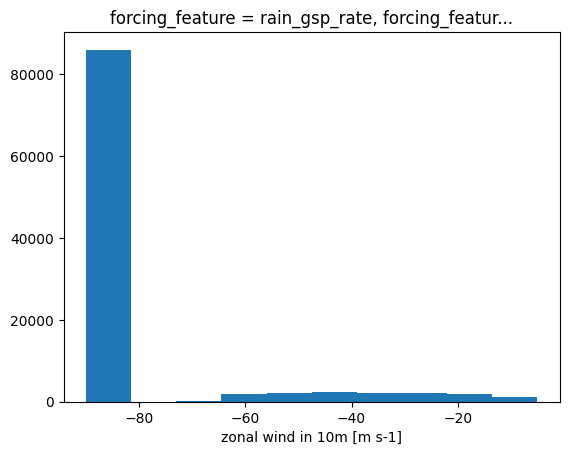

In [59]:
ds.forcing.sel(forcing_feature='rain_gsp_rate').isel(time=0).plot.hist()

In [60]:
## Interior

In [65]:
ds_interior.attrs = None

In [70]:
ds_state = ds_interior.sel(state_feature=['rain_gsp_rate'])

In [71]:
data_transformed_w_zeros = xr.where(ds_state.state > 0, scipy.special.boxcox(ds_state.state, -0.1), -90)
ds_state["state"] = data_transformed_w_zeros

In [72]:
ds_split = ds_state.sel(
    {"time": slice(config['output']['splitting']['splits']['train']['start'], config['output']['splitting']['splits']['train']['end'])}
)


ds_state['state__train__diff_mean'] = ds_split.state.diff(dim='train').mean(dim=['time','grid_index'])
ds_state['state__train__diff_std'] = ds_split.state.diff(dim='train').std(dim=['time','grid_index'])
ds_state['state__train__mean'] = ds_split.state.mean(dim=['time','grid_index'])
ds_state['state__train__std'] = ds_split.state.std(dim=['time','grid_index'])

In [78]:
ds_state_out = ds_state.drop_vars(['forcing', 'forcing__train__diff_mean', 'forcing__train__diff_std', 'forcing__train__mean',
                    'forcing__train__std', 'splits', 'static', 'static__train__mean', 'static__train__std', 'clat', 'clon',])

In [79]:
encoding = {}
for var in ds_state_out.data_vars:
    encoding[var] = {'compressor': ds_interior[var].encoding['compressor']}

ds_state_out.to_zarr("../data/experiment/data/datastore.interior.domain03.boxcoxrain.zarr", mode='w', encoding=encoding)